<a href="https://colab.research.google.com/github/tupii-7/Data-Visualization/blob/main/paktikum6_said_fachri_ariza_60324023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

df["age"] = df["age"].fillna(df["age"].mean())
df = df.dropna(subset=["embarked"])
df = df.drop_duplicates()

print("Data siap divisualisasikan:", df.shape)


Data siap divisualisasikan: (782, 15)


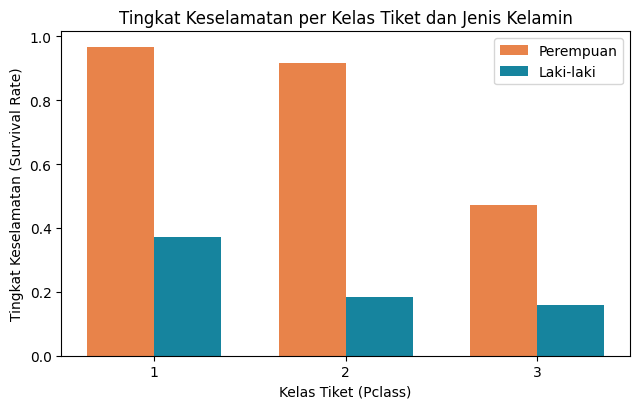

In [4]:
pt = df.pivot_table(values="survived", index="pclass", columns="sex", aggfunc="mean")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
x = np.arange(len(pt.index))
width = 0.35

ax.bar(x - width/2, pt["female"], width, label="Perempuan", color="#E8834A")
ax.bar(x + width/2, pt["male"], width, label="Laki-laki", color="#16849E")

ax.set_title("Tingkat Keselamatan per Kelas Tiket dan Jenis Kelamin")
ax.set_xticks(x)
ax.set_xticklabels(pt.index)

# Tambahkan baris ini untuk memunculkan legend
ax.legend()

# Opsional: tambahkan label sumbu agar lebih informatif
ax.set_xlabel("Kelas Tiket (Pclass)")
ax.set_ylabel("Tingkat Keselamatan (Survival Rate)")

plt.tight_layout()
plt.show()

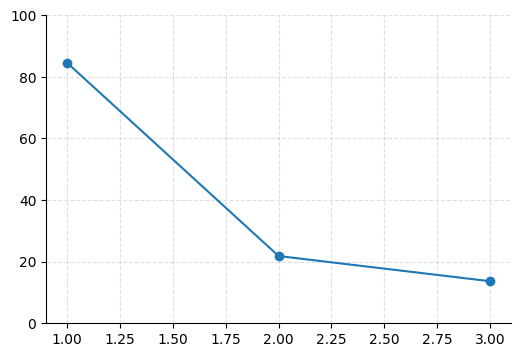

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

rata_fare = df.groupby("pclass")["fare"].mean()

ax.plot(rata_fare.index, rata_fare.values, marker="o")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

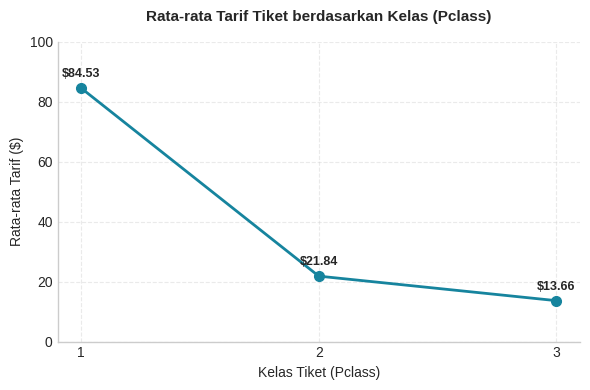

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# 1. Olah Data
rata_fare = df.groupby("pclass")["fare"].mean()

# 2. Plot Garis dengan Custom Style
ax.plot(
    rata_fare.index,
    rata_fare.values,
    marker="o",
    color="#16849E",
    linewidth=2,
    markersize=7,
    label="Rata-rata Tarif"
)

# 3. Tambahkan Nilai Nominal di Atas Marker (Rinci)
for x, y in zip(rata_fare.index, rata_fare.values):
    ax.annotate(
        f"${y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# 4. Judul dan Label Sumbu Lengkap
ax.set_title("Rata-rata Tarif Tiket berdasarkan Kelas (Pclass)", fontsize=11, fontweight="bold", pad=15)
ax.set_xlabel("Kelas Tiket (Pclass)", fontsize=10)
ax.set_ylabel("Rata-rata Tarif ($)", fontsize=10)

# 5. Pengaturan Ticks, Grid, dan Spine
ax.set_xticks(rata_fare.index)
ax.set_ylim(0, 100)
ax.grid(True, linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

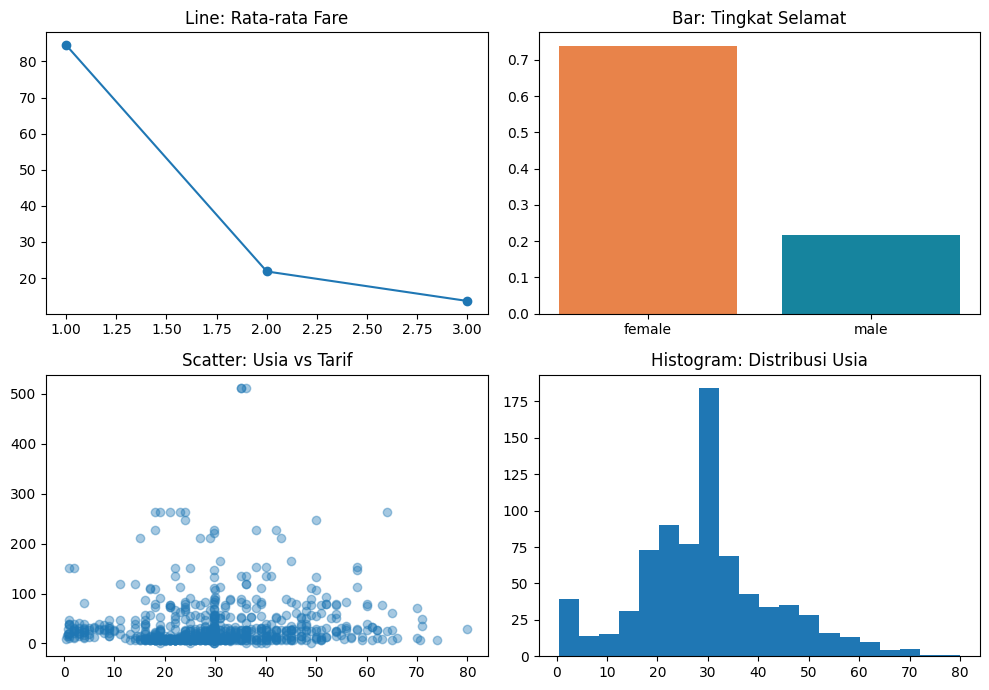

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

tingkat = df.groupby("sex")["survived"].mean()

axes[0, 0].plot(rata_fare.index, rata_fare.values, marker="o")
axes[0, 0].set_title("Line: Rata-rata Fare")

# Memberikan warna berbeda untuk female dan male
colors = ["#E8834A" if sex == "female" else "#16849E" for sex in tingkat.index]
axes[0, 1].bar(tingkat.index, tingkat.values, color=colors)
axes[0, 1].set_title("Bar: Tingkat Selamat")

axes[1, 0].scatter(df["age"], df["fare"], alpha=0.4)
axes[1, 0].set_title("Scatter: Usia vs Tarif")

axes[1, 1].hist(df["age"], bins=20)
axes[1, 1].set_title("Histogram: Distribusi Usia")

plt.tight_layout()
plt.show()

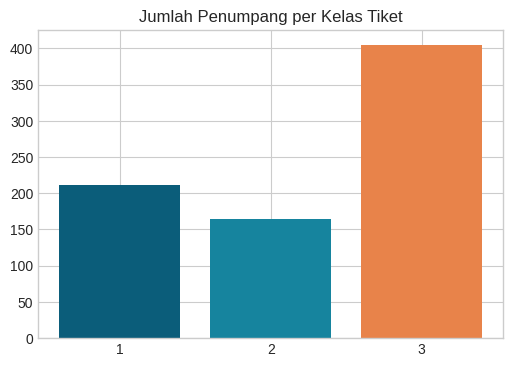

In [14]:
# Palet warna kustom bergaya course branding
palet = ["#0B5D7A", "#16849E", "#E8834A"]
jumlah_kelas = df["pclass"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah_kelas.index.astype(str), jumlah_kelas.values, color=palet)
ax.set_title("Jumlah Penumpang per Kelas Tiket")
plt.show()

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


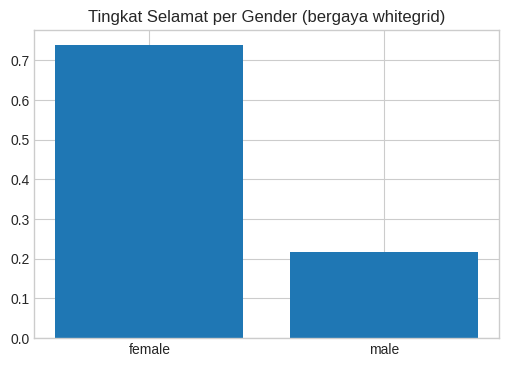

In [17]:
print(plt.style.available)  # lihat daftar gaya tersedia

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tingkat.index, tingkat.values)
ax.set_title("Tingkat Selamat per Gender (bergaya whitegrid)")

plt.show()

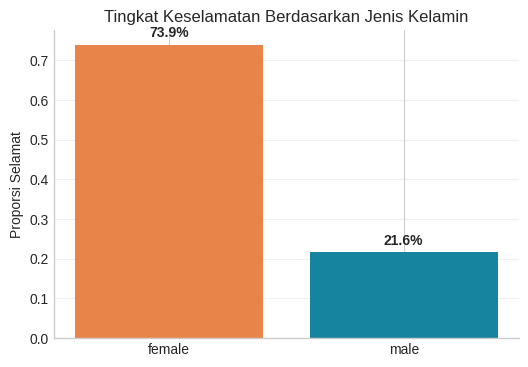

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(tingkat.index, tingkat.values, color=["#E8834A", "#16849E"])

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.1%}",
        ha="center",
        fontweight="bold"
    )

ax.set_title("Tingkat Keselamatan Berdasarkan Jenis Kelamin")
ax.set_ylabel("Proporsi Selamat")
ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Latihan 1
Buat grouped bar chart jumlah penumpang (bukan proporsi) berdasarkan `pclass` dan `embark_town`, lengkap dengan legenda.

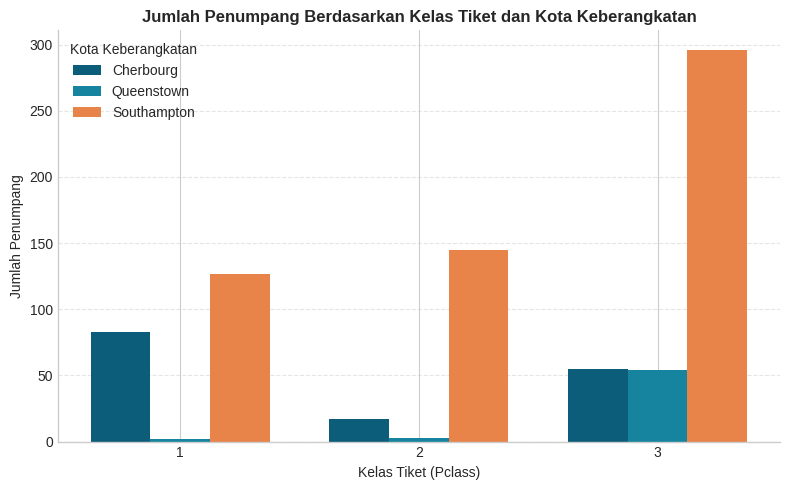

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Agregasi data jumlah penumpang berdasarkan pclass dan embark_town
pax_count = df.pivot_table(index="pclass", columns="embark_town", values="survived", aggfunc="count").fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(pax_count.index))
width = 0.25

# Membuat grouped bar chart
bars1 = ax.bar(x - width, pax_count["Cherbourg"], width, label="Cherbourg", color="#0B5D7A")
bars2 = ax.bar(x, pax_count["Queenstown"], width, label="Queenstown", color="#16849E")
bars3 = ax.bar(x + width, pax_count["Southampton"], width, label="Southampton", color="#E8834A")

# Menambahkan label dan judul
ax.set_title("Jumlah Penumpang Berdasarkan Kelas Tiket dan Kota Keberangkatan", fontsize=12, fontweight="bold")
ax.set_xlabel("Kelas Tiket (Pclass)", fontsize=10)
ax.set_ylabel("Jumlah Penumpang", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(pax_count.index)
ax.legend(title="Kota Keberangkatan")
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Latihan 2
Susun grid subplot 1x2 yang membandingkan histogram usia penumpang yang selamat vs tidak selamat (filter `survived==1` dan `survived==0`).

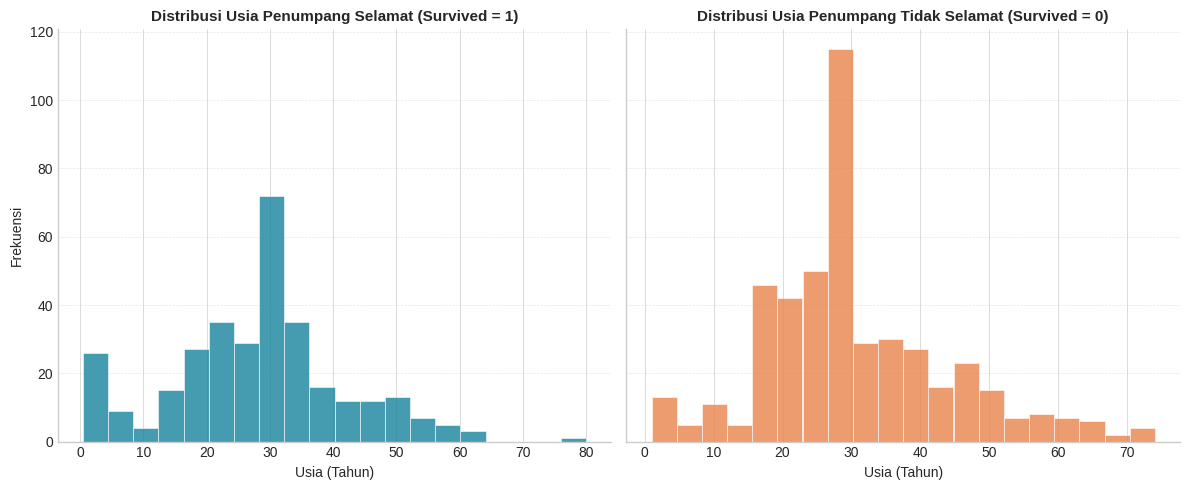

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Filter data selamat dan tidak selamat
selamat = df[df["survived"] == 1]["age"]
tidak_selamat = df[df["survived"] == 0]["age"]

# 1. Plot histogram untuk penumpang selamat
axes[0].hist(selamat, bins=20, color="#16849E", edgecolor="white", alpha=0.8)

axes[0].set_title("Distribusi Usia Penumpang Selamat (Survived = 1)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Usia (Tahun)", fontsize=10)
axes[0].set_ylabel("Frekuensi", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# 2. Plot histogram untuk penumpang tidak selamat
axes[1].hist(tidak_selamat, bins=20, color="#E8834A", edgecolor="white", alpha=0.8)

axes[1].set_title("Distribusi Usia Penumpang Tidak Selamat (Survived = 0)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Usia (Tahun)", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Latihan 3
Coba minimal 2 gaya (style) Matplotlib yang berbeda (misalnya `ggplot` dan `bmh`) pada grafik yang sama, lalu bandingkan tampilannya.

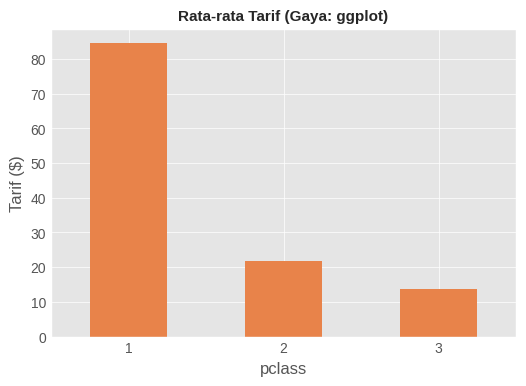

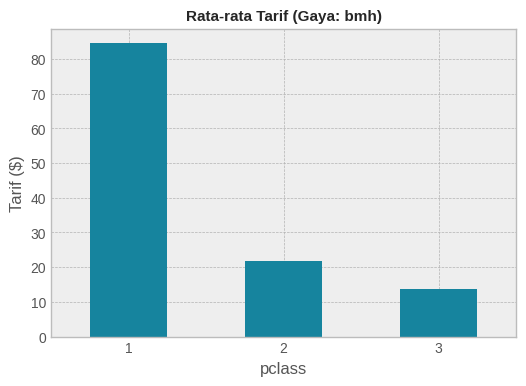

In [27]:
import matplotlib.pyplot as plt

# Menyimpan style default agar bisa dikembalikan nanti
default_style = plt.rcParams.copy()

# 1. Menggunakan Style 'ggplot'
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(6, 4))
rata_fare.plot(kind="bar", ax=ax, color="#E8834A")

ax.set_title("Rata-rata Tarif (Gaya: ggplot)", fontsize=11, fontweight="bold")
ax.set_ylabel("Tarif ($)")
plt.xticks(rotation=0)  # Membuat angka sumbu X lurus / tidak miring

plt.show()

# 2. Menggunakan Style 'bmh'
plt.style.use("bmh")

fig, ax = plt.subplots(figsize=(6, 4))
rata_fare.plot(kind="bar", ax=ax, color="#16849E")

ax.set_title("Rata-rata Tarif (Gaya: bmh)", fontsize=11, fontweight="bold")
ax.set_ylabel("Tarif ($)")
plt.xticks(rotation=0)  # Membuat angka sumbu X lurus / tidak miring

plt.show()

# Mengembalikan style ke semula (seaborn-v0_8-whitegrid yang digunakan sebelumnya)
plt.style.use("seaborn-v0_8-whitegrid")

### Latihan 4
Tambahkan garis rata-rata (`ax.axhline()`) pada salah satu bar chart Anda untuk menunjukkan rata-rata keseluruhan sebagai pembanding.

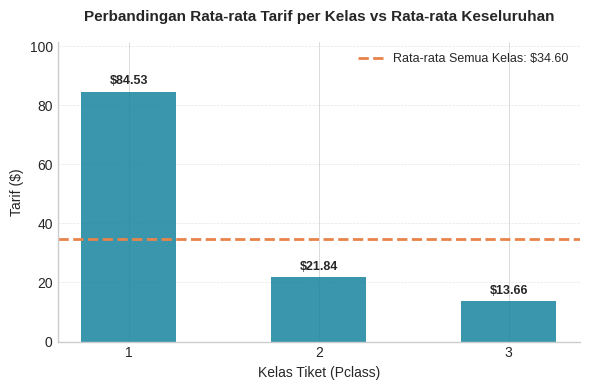

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

# Plot bar rata-rata tarif per pclass
bars = ax.bar(
    rata_fare.index.astype(str),
    rata_fare.values,
    color="#16849E",
    alpha=0.85,
    width=0.5
)

# Menambahkan Label Angka di Atas Batang
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"${bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Hitung rata-rata tarif keseluruhan
tarif_keseluruhan = df["fare"].mean()

# Tambahkan garis horizontal rata-rata keseluruhan
ax.axhline(
    tarif_keseluruhan,
    color="#E8834A",
    linestyle="--",
    linewidth=2,
    label=f"Rata-rata Semua Kelas: ${tarif_keseluruhan:.2f}"
)

# Pengaturan Judul, Label, dan Tampilan
ax.set_title("Perbandingan Rata-rata Tarif per Kelas vs Rata-rata Keseluruhan", fontsize=11, fontweight="bold", pad=15)
ax.set_xlabel("Kelas Tiket (Pclass)", fontsize=10)
ax.set_ylabel("Tarif ($)", fontsize=10)
ax.set_ylim(0, max(rata_fare.values) * 1.2)  # Memberi ruang agar label atas tidak terpotong
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Latihan 5
Buat satu set warna kustom (list HEX) bertema sendiri (bebas, konsisten), lalu terapkan pada minimal 2 grafik berbeda dalam notebook.

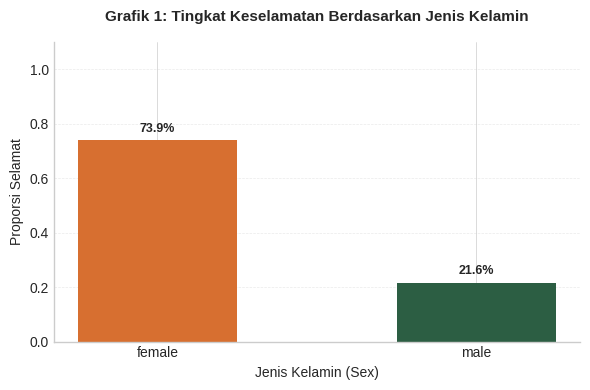

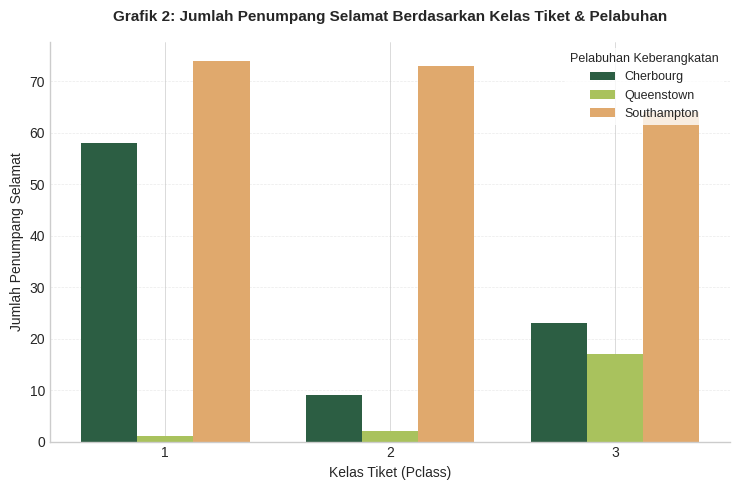

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Palet Warna Kustom Bertema 'Forest & Sand'
tema_kustom = ["#2C5E43", "#A9C25D", "#E0A96D", "#D76F30"]

# -----------------------------------------------------------------------------
# GRAFIK 1: Bar Chart Tingkat Keselamatan Berdasarkan Jenis Kelamin
# -----------------------------------------------------------------------------
tingkat_gender = df.groupby("sex")["survived"].mean()

fig, ax1 = plt.subplots(figsize=(6, 4))

bars1 = ax1.bar(
    tingkat_gender.index,
    tingkat_gender.values,
    color=[tema_kustom[3], tema_kustom[0]],
    width=0.5
)

# Menambahkan Data Label di Atas Bar
for bar in bars1:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax1.set_title(
    "Grafik 1: Tingkat Keselamatan Berdasarkan Jenis Kelamin",
    fontsize=11,
    fontweight="bold",
    pad=15
)
ax1.set_xlabel("Jenis Kelamin (Sex)", fontsize=10)
ax1.set_ylabel("Proporsi Selamat", fontsize=10)
ax1.set_ylim(0, 1.1)  # Memberi ruang agar label atas tidak terpotong
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# GRAFIK 2: Grouped Bar Chart Penumpang Selamat Berdasarkan Kelas & Pelabuhan
# -----------------------------------------------------------------------------
pt_embark = df[df["survived"] == 1].pivot_table(
    values="survived",
    index="pclass",
    columns="embark_town",
    aggfunc="count"
).fillna(0)

fig, ax2 = plt.subplots(figsize=(7.5, 5))

x = range(len(pt_embark.index))
width = 0.25

for i, col in enumerate(pt_embark.columns):
    offset = (i - len(pt_embark.columns) / 2) * width + width / 2
    ax2.bar(
        [pos + offset for pos in x],
        pt_embark[col],
        width,
        label=col,
        color=tema_kustom[i % len(tema_kustom)]
    )

ax2.set_title(
    "Grafik 2: Jumlah Penumpang Selamat Berdasarkan Kelas Tiket & Pelabuhan",
    fontsize=11,
    fontweight="bold",
    pad=15
)
ax2.set_xlabel("Kelas Tiket (Pclass)", fontsize=10)
ax2.set_ylabel("Jumlah Penumpang Selamat", fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(pt_embark.index)

# Merapikan tampilan legenda: meletakkannya di posisi optimal dengan background semi-transparan
ax2.legend(
    title="Pelabuhan Keberangkatan",
    title_fontsize=9,
    fontsize=9,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    shadow=False
)

ax2.grid(axis="y", linestyle="--", alpha=0.4)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Direview oleh: irfan ali

1. Apakah setiap grafik memiliki judul yang jelas? Ya
2. Apakah label sumbu X dan Y sudah ada dan informatif? Ya
3. Apakah grafik dengan beberapa kategori memiliki legenda? Ya
4. Apakah pemilihan warna cukup kontras dan mudah dibedakan? Ya
5. Satu hal yang paling baik dari grafik ini: Penggunaan palet warna kustom bertema Forest & Sand memberikan estetika visual yang konsisten, modern, dan sangat profesional. Penempatan data label di atas batang (bar) pada grafik tingkat keselamatan juga memudahkan audiens membaca nilai persentase secara presisi tanpa harus menerka-nerka dari sumbu Y.
6. Satu saran perbaikan untuk grafik ini: Untuk mempercantik visualisasi lebih lanjut, batas bingkai bagian atas dan kanan (spines) pada beberapa grafik seperti di Latihan 1 dan Latihan 5 dapat disembunyikan menggunakan ax.spines['top'].set_visible(False) secara konsisten agar tampilan grafik terlihat lebih bersih dan minimalis.


